# 3.0 Data Preparation

Runs 3.1 → 3.2 → 3.3 → 3.4 in sequence, with the real code and visuals used as evidence in the report.

## Setup

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))
import matplotlib.pyplot as plt
import pandas as pd

from src.data_cleaning import load_raw, clean
from src.outlier_treatment import treat_outliers, compute_iqr_bounds, audit_iqr
from src.data_transformation import transform, get_engineered_feature_lists, TOP_AMENITIES
from final_dataset_output import build_final_dataset, RAW_CSV_PATH

# notebooks/ runs with a different cwd than the repo root — adjust the relative path
RAW_CSV_PATH = "../" + RAW_CSV_PATH

## 3.1 Data Selection
The excluded columns are dropped inside `clean()` below, per the decisions recorded in `src/config.py`. The data is selected based on previous data understanding studies

Below are some code to justify the report findings

In [2]:
df_raw = load_raw(RAW_CSV_PATH)

# currency check only have USD
is_only_usd = list(df_raw['currency'].unique()) == ['USD']
print(is_only_usd)

True


In [3]:
#shows the distribution of the category column in percentage and counts
print(df_raw['category'].value_counts(normalize=True) * 100)
print(df_raw['category'].value_counts())

category
housing/rent/apartment            99.938689
housing/rent/commercial/retail     0.042214
housing/rent                       0.007036
housing/rent/home                  0.004020
housing/rent/short_term            0.004020
housing/rent/condo                 0.003015
housing/rent/other                 0.001005
Name: proportion, dtype: float64
category
housing/rent/apartment            99431
housing/rent/commercial/retail       42
housing/rent                          7
housing/rent/home                     4
housing/rent/short_term               4
housing/rent/condo                    3
housing/rent/other                    1
Name: count, dtype: int64


In [4]:
#shows the distribution of the price_type column in percentage and counts
print(df_raw['price_type'].value_counts(normalize=True) * 100)
print(df_raw['price_type'].value_counts())

price_type
Monthly           99.995980
Weekly             0.003015
Monthly|Weekly     0.001005
Name: proportion, dtype: float64
price_type
Monthly           99488
Weekly                3
Monthly|Weekly        1
Name: count, dtype: int64


In [5]:
#shows the how many null percentage values in the address column
print(df_raw['address'].isnull().value_counts(normalize=True) * 100)

address
True     92.016444
False     7.983556
Name: proportion, dtype: float64


## 3.2 Data Cleaning
As established in Section 2.3 (Findings 1–4) of the Data Understanding section, the raw file has 84 duplicate `id` values and several missing-value issues. This section applies the cleaning steps and shows the resulting counts as evidence.

In [6]:
df_raw = load_raw(RAW_CSV_PATH)
print('Raw shape:', df_raw.shape)
df_clean = clean(df_raw, verbose=True)

Raw shape: (99492, 22)
[3.2.1] Removed 84 duplicate listings (matched on id)
[3.2.2] Removed 65 non-standard-apartment / non-monthly rows
[3.2.3] Removed 483 rows with missing critical values

Final shape: (98860, 12)  (kept 99.4% of raw rows)
Missing values remaining:
 amenities       0
bathrooms       0
bedrooms        0
fee             0
has_photo       0
pets_allowed    0
price           0
square_feet     0
cityname        0
state           0
latitude        0
longitude       0
dtype: int64


**Note on the duplicate check**: matching on `id` (not on the remaining columns) matters here. An earlier check that compared rows on every column *except* id/address flagged over 7,500 rows as 'duplicates' — but those had different `id`s and turned out to be legitimate separate listings (e.g. multiple identical units in the same apartment complex, same floor plan and rent). Only the 84 rows sharing an actual `id` were removed.

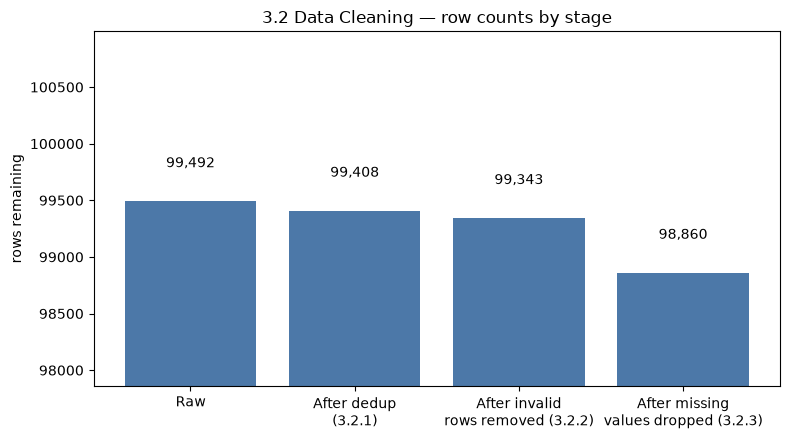

In [7]:
fig, ax = plt.subplots(figsize=(8,4.5))
stages = ['Raw', 'After dedup\n(3.2.1)', 'After invalid\nrows removed (3.2.2)', 'After missing\nvalues dropped (3.2.3)']
counts = [len(df_raw), len(df_raw)-84, len(df_raw)-84-65, len(df_clean)]
ax.bar(stages, counts, color='#4C78A8')
for i, c in enumerate(counts):
    ax.text(i, c+300, f'{c:,}', ha='center', fontsize=10)
ax.set_ylabel('rows remaining')
ax.set_title('3.2 Data Cleaning — row counts by stage')
ax.set_ylim(min(counts)-1000, max(counts)+1500)
fig.tight_layout()
fig.savefig('../outputs/figures/32_cleaning_stages.png', dpi=120)
plt.show()

## 3.3 Outlier Treatment
IQR bounds computed on the cleaned dataset, applied as a cap (not row removal) 

In [17]:
audit_iqr(df_clean, ["price", "square_feet", "bathrooms", "bedrooms"], k=1.5)

Variable          Count      Mean        SD       Min       25%    Median       75%       Max       Lower       Upper   Flagged
-------------------------------------------------------------------------------------------------------------------------------
price             98860   1525.48    898.98    100.00   1013.00   1350.00   1795.00  52500.00     -160.00     2968.00      4614
square_feet       98860    955.99    365.31    107.00    730.00    900.00   1115.00  12000.00      152.50     1692.50      2827
bathrooms         98860      1.45      0.55      1.00      1.00      1.00      2.00      9.00       -0.50        3.50       201
bedrooms          98860      1.73      0.75      0.00      1.00      2.00      2.00      9.00       -0.50        3.50      1829


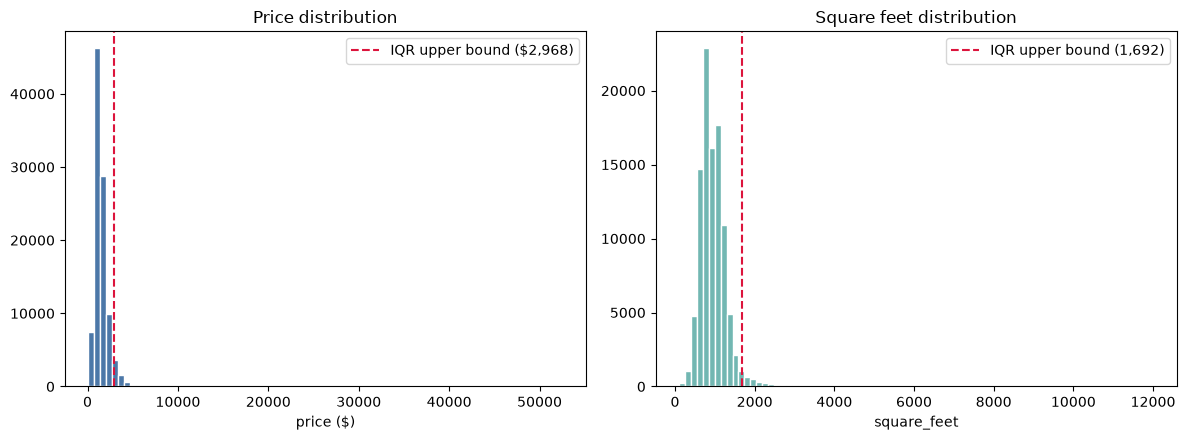

In [9]:
lower_p, upper_p = compute_iqr_bounds(df_clean, 'price')
lower_s, upper_s = compute_iqr_bounds(df_clean, 'square_feet')

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].hist(df_clean['price'], bins=80, color='#4C78A8', edgecolor='white')
axes[0].axvline(upper_p, color='crimson', linestyle='--', label=f'IQR upper bound (${upper_p:,.0f})')
axes[0].set_title('Price distribution'); axes[0].set_xlabel('price ($)'); axes[0].legend()

axes[1].hist(df_clean['square_feet'], bins=80, color='#72B7B2', edgecolor='white')
axes[1].axvline(upper_s, color='crimson', linestyle='--', label=f'IQR upper bound ({upper_s:,.0f})')
axes[1].set_title('Square feet distribution'); axes[1].set_xlabel('square_feet'); axes[1].legend()

fig.tight_layout()
fig.savefig('../outputs/figures/33_outlier_bounds.png', dpi=120)
plt.show()

In [10]:
df_capped = treat_outliers(df_clean, verbose=True)

[3.4] price: capped 4614 rows (4.67%) above 2,968 (IQR upper bound)
[3.4] square_feet: capped 2827 rows (2.86%) above 1,692 (IQR upper bound)
[3.4] bathrooms: capped 201 rows (0.20%) above 4 (IQR upper bound)
[3.4] bedrooms: capped 1829 rows (1.85%) above 4 (IQR upper bound)


## 3.4 Data Transformation
Amenity/pets multi-label engineering, room density feature, and hybrid city encoding.

In [11]:
df_transformed = transform(df_capped)
numeric, categorical = get_engineered_feature_lists(df_transformed)

print('Numeric features (', len(numeric), '):', numeric)
print()
print('Categorical features (', len(categorical), '):', categorical)

Numeric features ( 21 ): ['bathrooms', 'bedrooms', 'square_feet', 'latitude', 'longitude', 'amenity_count', 'squarefeet_per_room', 'allows_cats', 'allows_dogs', 'pets_policy_specified', 'amenity_has_parking', 'amenity_has_pool', 'amenity_has_gym', 'amenity_has_patio_deck', 'amenity_has_washer_dryer', 'amenity_has_storage', 'amenity_has_clubhouse', 'amenity_has_dishwasher', 'amenity_has_ac', 'amenity_has_fireplace', 'amenity_has_refrigerator']

Categorical features ( 4 ): ['state', 'fee', 'has_photo', 'city_category']


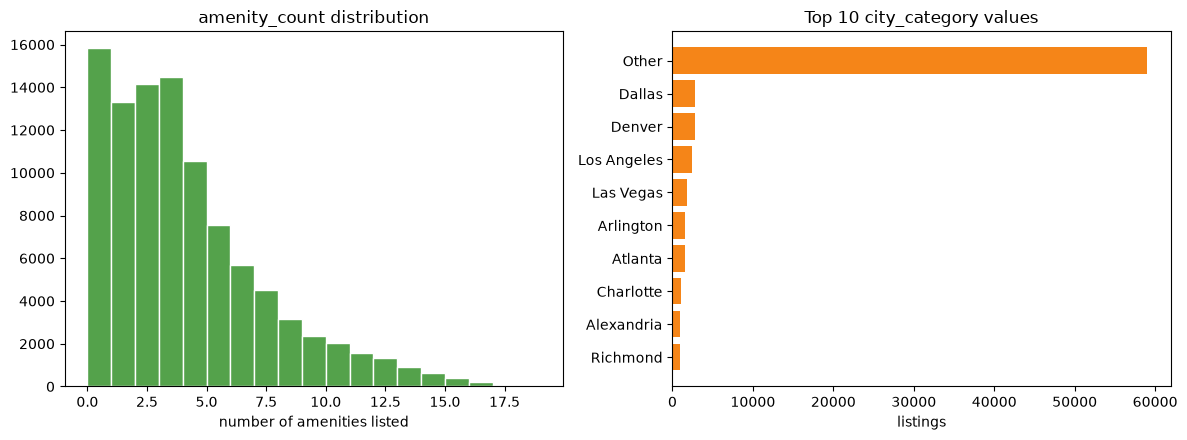

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

axes[0].hist(df_transformed['amenity_count'], bins=range(0,20), color='#54A24B', edgecolor='white')
axes[0].set_title('amenity_count distribution'); axes[0].set_xlabel('number of amenities listed')

city_counts = df_transformed['city_category'].value_counts().head(10)
axes[1].barh(city_counts.index[::-1], city_counts.values[::-1], color='#F58518')
axes[1].set_title('Top 10 city_category values')
axes[1].set_xlabel('listings')

fig.tight_layout()
fig.savefig('../outputs/figures/34_transformation_features.png', dpi=120)
plt.show()

In [13]:
print('pets_allowed split into binary flags:')
print(df_transformed[['allows_cats','allows_dogs','pets_policy_specified']].sum())

pets_allowed split into binary flags:
allows_cats              38726
allows_dogs              37020
pets_policy_specified    38852
dtype: int64


## 3.5 Final Prepared Dataset
Runs the full pipeline in the correct order (3.2 → 3.3 → 3.4) via `build_final_dataset()`, and writes the model-ready CSV.

In [14]:
final_df = build_final_dataset(raw_csv_path=RAW_CSV_PATH, verbose=True)
final_df.to_csv('../data/apartments_prepared.csv', index=False)
final_df.head()

Raw shape: (99492, 22)
[3.2.1] Removed 84 duplicate listings (matched on id)
[3.2.2] Removed 65 non-standard-apartment / non-monthly rows
[3.2.3] Removed 483 rows with missing critical values

Final shape: (98860, 12)  (kept 99.4% of raw rows)
Missing values remaining:
 amenities       0
bathrooms       0
bedrooms        0
fee             0
has_photo       0
pets_allowed    0
price           0
square_feet     0
cityname        0
state           0
latitude        0
longitude       0
dtype: int64
[3.4] price: capped 4614 rows (4.67%) above 2,968 (IQR upper bound)
[3.4] square_feet: capped 2827 rows (2.86%) above 1,692 (IQR upper bound)
[3.4] bathrooms: capped 201 rows (0.20%) above 4 (IQR upper bound)
[3.4] bedrooms: capped 1829 rows (1.85%) above 4 (IQR upper bound)

Final prepared dataset: (98860, 26)
Features: 25 (21 numeric, 4 categorical)


,bathrooms,bedrooms,square_feet,latitude,longitude,amenity_count,squarefeet_per_room,allows_cats,allows_dogs,pets_policy_specified,...,amenity_has_clubhouse,amenity_has_dishwasher,amenity_has_ac,amenity_has_fireplace,amenity_has_refrigerator,state,fee,has_photo,city_category,price
0,1.0,1.0,542.0,33.8520,-118.3759,0,271.000000,1,0,1,...,0,0,0,0,0,CA,No,Thumbnail,Other,2195.0
1,1.5,3.0,1500.0,37.0867,-76.4941,0,333.333333,1,1,1,...,0,0,0,0,0,VA,No,Thumbnail,Newport News,1250.0
2,2.0,3.0,1650.0,35.8230,-78.6438,0,330.000000,0,0,0,...,0,0,0,0,0,NC,No,Thumbnail,Raleigh,1395.0
3,1.0,2.0,820.0,38.3622,-121.9712,0,273.333333,1,1,1,...,0,0,0,0,0,CA,No,Thumbnail,Other,1600.0
4,1.0,1.0,624.0,35.1038,-106.6110,0,312.000000,1,1,1,...,0,0,0,0,0,NM,No,Thumbnail,Other,975.0


In [15]:
from sklearn.model_selection import train_test_split

numeric, categorical = get_engineered_feature_lists(final_df)
X = final_df[numeric + categorical]
y = final_df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Train price mean: ${:.2f}  |  Test price mean: ${:.2f}'.format(y_train.mean(), y_test.mean()))

Train: (79088, 25) Test: (19772, 25)
Train price mean: $1477.35  |  Test price mean: $1466.89
